# Исследование данных о российском кинопрокате


**Оглавление**
1. [Описание данных](#Описание-данных)
2. [Начало работы](#Начало-работы)
3. [Предобработка данных](#Предобработка-данных)
    - 3.1. [Изменение типов данных](#Изменение-типов-данных)
    - 3.2. [Обработка пропусков](#Обработка-пропусков)
    - 3.3. [Обработка явных дубликатов](#Обработка-явных-дубликатов)
    - 3.4. [Обработка неявных дубликатов](#Обработка-неявных-дубликатов)
    - 3.5. [Проверка аномальных значений](#Проверка-аномальных-значений)
    - 3.6. [Добавление новых столбцов](#Добавление-новых-столбцов)
4. [Исследовательский анализ данных](#Исследовательский-анализ-данных)
    - 4.1. [Рассчет доли государственной поддержки](#Рассчет-доли-государственной-поддержки)
    - 4.2. [Определение периода с наиболее полно представленного данными](#Определение-периода-с-наиболее-полно-представленного-данными)
    - 4.3. [Динамика проката по годам. Определение среднего и медианы](#Динамика-проката-по-годам-Определение-среднего-и-медианы)
    - 4.4. [Влияние возрастного ограничения на сумму проката](#Влияние-возрастного-ограничения-на-сумму-проката)
    - 4.5. [Исследование фильмов с государственной поддержкой](#Исследование-фильмов-с-государственной-поддержкой)
5. [Общий вывод](#Общий-вывод)

## Описание данных

**Заказчик этого исследования** — Министерство культуры Российской Федерации. 
    
**Цель** - изучить рынок российского кинопроката и выявить текущие тренды. Уделить внимание фильмам, которые получили государственную поддержку. Ответить на вопрос, насколько такие фильмы интересны зрителю. 

**Данные** опубликованы на [портале открытых данных Министерства культуры](https://opendata.mkrf.ru/) и содержит информацию о прокатных удостоверениях, сборах и государственной поддержке фильмов, а также информацию с сайта [КиноПоиск](https://www.kinopoisk.ru/). 

Таблица `mkrf_movies` содержит информацию из реестра прокатных удостоверений. У одного фильма может быть несколько прокатных удостоверений. 
- `title` — название фильма;
- `puNumber` — номер прокатного удостоверения;
- `show_start_date` — дата премьеры фильма;
- `type` — тип фильма;
- `film_studio` — студия-производитель;
- `production_country` — страна-производитель;
- `director` — режиссёр;
- `producer` — продюсер;
- `age_restriction` — возрастная категория;
- `refundable_support` — объём возвратных средств государственной поддержки;
- `nonrefundable_support` — объём невозвратных средств государственной поддержки;
- `financing_source` — источник государственного финансирования;
- `budget` — общий бюджет фильма;
- `ratings` — рейтинг фильма на КиноПоиске;
- `genres` — жанр фильма.

Таблица `mkrf_shows` содержит сведения о показах фильмов в российских кинотеатрах.
- `puNumber` — номер прокатного удостоверения;
- `box_office` — сборы в рублях.

## Начало работы

Объедините данные таким образом, чтобы все объекты из датасета `mkrf_movies` обязательно вошли в получившийся датафрейм. 


In [10]:
# импорт необходимых библиотек
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# при выводе датафрейма будут показываться все колонки
pd.set_option('display.max_columns', None)

# определим формат даты
date_format = '%Y-%m-%dT%H:%M:%S.%fZ'

# настроим отображение чисел больших порядков в привычном виде
pd.set_option("display.float_format", "{:.2f}".format)

# установим максимальную длину отображаемых строк
pd.set_option('display.max_colwidth', None)

In [11]:
try:
    df = pd.read_csv('mkrf_movies.csv')
    
except:
    df = pd.read_csv('https://code.s3.yandex.net/datasets/mkrf_movies.csv') 

df.head()

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикчерз, Тиг Продакшнз",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама"
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный"
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Платт Продакшнз, Рилейтивити Медиа, Спайгласс Интертейнмент, Стилкин Филмз, Топ Кау Продакшнз",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Платт Продакшнз, Рилейтивити Медиа, Спайгласс Интертейнмент, Стилкин Филмз, Топ Кау Продакшнз",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Платт Продакшнз, Рилейтивити Медиа, Спайгласс Интертейнмент, Стилкин Филмз, Топ Кау Продакшнз",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"


In [12]:
try:  
    sub_df = pd.read_csv('mkrf_shows.csv')
    
except:  
    sub_df = pd.read_csv('https://code.s3.yandex.net/datasets/mkrf_shows.csv')
    
sub_df.head()

,puNumber,box_office
0,111000113,2450.00
1,111000115,61040.00
2,111000116,153030013.40
3,111000117,12260956.00
4,111000118,163684057.79


Выведем общую информацию о датафреймах.

In [14]:
df.info()
print('')
sub_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   object 
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
dtypes: f

Видим, что значения в столбце `puNumber` отличаются у один и тех же индексов в двух датафреймах. Поэтому применять метод `.join` некорректно, используем `.merge`. Однако у выбранного столбца разные типы данных в двух датафреймах. Изучим почему.

In [16]:
# sort_values по умолчанию сортирует в порядке возрастания
# буквы имеют бОльшое значение в кодировке UNICODE, значит будут в конце списка
# отобразим последние строки
df.sort_values(by = 'puNumber').tail() 

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
4355,Первый рай,226017410,2010-05-04T12:00:00.000Z,Прочие,Би-Би-Си,Великобритания,Дэвид Аттенборо,NaN,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,7.4,"мультфильм,короткометражка,мелодрама"
3992,"Дэвид Гилмор ""Римемба Зет Найт""",226019110,2010-05-14T12:00:00.000Z,Художественный,Дэвид Гилмор Мьюзик,Великобритания,Дэвид Маллет,Дайоуни Орром,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.4,"триллер,драма,детектив"
1011,ТотКтоПрошелСквозьОгонь,231001012,2015-04-23T12:00:00.000Z,Художественный,"Министерство культуры Украины, Государственное агентство Украины по вопросам кино, ООО ""ИнсайтМедиа"" продюсерский центр",Украина,М.Ильенко,В.Филиппов,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.2,"драма,приключения,биография"
5249,Мелодия для шарманки,231001111,2011-12-27T12:00:00.000Z,Художественный,Сота Синема Груп,Украина,Кира Муратова,Олег Кохан,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,6.7,драма
1797,Курбан-роман. (История с жертвой),нет,2014-05-15T12:00:00.000Z,Художественный,"ФОНД ""ИННОВАЦИЯ""",Россия,С.Юзеев,М.Галицкая,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN


Наличие значения с буквами `нет` не даст поменять тип столбца на целочисленный, удалим эту строку.

In [18]:
df = df[df.index != 1797] # обратимся к строке через ее индекс
df.shape # проверим, что количество строк уменьшилось на 1

(7485, 15)

Теперь мы готовы поменять тип столбца на `int`.

In [20]:
df.puNumber = df.puNumber.astype('int', errors='ignore')

Объединим два датафрейма, причем все значения из датасета `mkrf_movies`, сохраненный в переменной `df`, должны остаться.

In [22]:
df = df.merge(sub_df, on = 'puNumber', how = 'left')
df.head()

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикчерз, Тиг Продакшнз",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Платт Продакшнз, Рилейтивити Медиа, Спайгласс Интертейнмент, Стилкин Филмз, Топ Кау Продакшнз",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Платт Продакшнз, Рилейтивити Медиа, Спайгласс Интертейнмент, Стилкин Филмз, Топ Кау Продакшнз",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Платт Продакшнз, Рилейтивити Медиа, Спайгласс Интертейнмент, Стилкин Филмз, Топ Кау Продакшнз",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN


## Предобработка данных

### Изменение типов данных

- Проверьте типы данных в датафрейме и преобразуйте их там, где это необходимо.

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7485 entries, 0 to 7484
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7485 non-null   object 
 1   puNumber               7485 non-null   int64  
 2   show_start_date        7485 non-null   object 
 3   type                   7485 non-null   object 
 4   film_studio            7467 non-null   object 
 5   production_country     7483 non-null   object 
 6   director               7476 non-null   object 
 7   producer               6917 non-null   object 
 8   age_restriction        7485 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
 15  box_

---

Столбец `show_start_date` содержит информацию о дате премьеры фильма, изменим тип значений на `datetime`. Формат возьмем из переменной `date_format`, которую мы обозначили в начале работы.

In [29]:
df.show_start_date = pd.to_datetime(df.show_start_date, format = date_format)

---

Столбец `ratings` содержит рейтинг фильмов, по логике значения должны быть числами с плавающей точкой, но в df этот столбец с типом `object`. Для начала выведем все уникальные значения.

In [34]:
df.ratings.unique()

array(['7.2', '6.6', '6.8', '7.7', '8.3', '8.0', '7.8', '8.1', '7.1',
       '6.0', '7.4', '5.8', '8.7', '6.3', '6.9', '5.0', '4.3', '7.3',
       '7.0', '6.4', nan, '8.2', '7.5', '6.7', '7.9', '5.9', '6.2', '5.6',
       '6.5', '2.4', '7.6', '6.1', '8.6', '8.5', '8.8', '5.5', '5.1',
       '5.7', '5.4', '99%', '4.4', '4.5', '5.3', '4.1', '8.4', '2.6',
       '3.8', '4.6', '4.8', '4.0', '3.0', '1.6', '4.2', '5.2', '4.7',
       '4.9', '3.9', '2.7', '3.3', '2.9', '28%', '3.7', '1.4', '3.1',
       '97%', '3.5', '3.2', '2.8', '1.5', '2.1', '2.5', '9.2', '3.4',
       '1.1', '3.6', '83%', '64%', '91%', '94%', '62%', '79%', '90%',
       '19%', '88%', '1.0', '89%', '1.3', '1.9', '1.8', '1.2', '1.7',
       '9.0', '98%', '8.9', '9.1'], dtype=object)

In [35]:
wrong_list = list(df.ratings[df.ratings.str.contains('%',na=False)])

Встречаются строки с процентами, изучим, что это за фильмы, отсортировав в порядке возрастания рейтинга.

In [37]:
df.query('ratings in @wrong_list').sort_values(by='ratings')

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
3430,Наурыз,131000217,2017-03-09 12:00:00,Художественный,Эс Джи,Республика Казахстан,Аскар Бисембин,"Олег Головашкин, Алмас Султангазин",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,19%,комедия,37960.00
811,От винта!,114000212,2012-08-06 12:00:00,Анимационный,"ЗАО ""Продюсерский центр ""Парадиз""",Россия,О.Лопато,"Г.Нерсисян, А.Манасарян, А.Нерсесян",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,28%,"детский,приключения,комедия",1740.00
2437,Самый рыжий Лис,111012715,2015-07-30 12:00:00,Художественный,"ООО ""Продюсерский центр ""Ленфильм""",Россия,А.Стреляная,"А.Котелевский, Э.Пичугин",«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,62%,"фэнтези,семейный",NaN
1898,Золушка /По сказке Шарля Перро/. Холодное торжество,121003615,2015-02-27 12:00:00,Художественный,"Женр Филмз, Уолт Дисней Пикчерз",США,Кеннет Брана,"Дэвид Бэррон, Саймон Кинберг, Эллисон Ширмур",«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,64%,"мюзикл,фэнтези,мелодрама",528732557.70
7158,Анна Каренина. Интимный дневник,111013919,2019-10-23 12:00:00,Художественный,"ООО ""РТВ""",Россия,Ю.Грымов,Ю.Грымов,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,79%,драма,182882.50
2679,Год Белого Слона,111003915,2015-04-08 12:00:00,Художественный,"ООО ""Творческое объединение ЮГ""",Россия,Ю.Грымов,П.Поляков,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,79%,семейный,NaN
3445,Короткие истории о любви - 4,126006316,2016-12-30 12:00:00,Прочие,"Нетворг Айлэнд Телевижн, Магнетфильм, Шорткатс, Индивидуальный предприниматель Антохин Петр Александрович, Алекс Бурунова",Великобритания - Аргентина - США - Франция - Россия - Испания,"Д.Адар, П.Антохин, М.Биасин, А.Бурунова, К.Колинз, К.Россет, Д.Эверет","Д.Адар, Д.Амсон, П.Антохин, А.Армстронг, С.Бильбулен, А.Бурунова, Н.Джинчарадзе, А.Калво, К.Колинз, Х.П.Миллер, Д.Эверет",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,83%,NaN,2266408.00
5454,Вечный холод,111006417,2017-08-28 12:00:00,Художественный,"ЗАО ""Производственный комплекс ""ГЛАВКИНО"", ООО ""Лунапарк Продакшн""",Россия,А.Мигачев,И.Бачурин,«18+» - запрещено для детей,NaN,NaN,NaN,NaN,83%,"фэнтези,боевик,триллер",NaN
1873,Короткие истории о любви 2,121002615,2015-02-13 12:00:00,Художественный,"Кавиар, Курт 13, СтритЛайт Филмз, Нэйер Дойче Генрефилм, Литиум Студиос/Дарк Хоуп Интертейнмент/Си Би Эс, Отр де Минюи, Хаусбленд Медиа, Летс Нот Лозе Продакшнз, Артс Институт Бурнемут",Нидерланды - США - Германия - Канада - Франция - Ирландия - Великобритания,"Мэтью Аувро, Лео Брайдл, Бен Бренд, Ден Кларк, Шимми Маркус, Рамин Серри, Джош Соскин, Линси Стюарт, Рей Тинтори, Бен Томас, Хольгер Фрик","Мэри Пэт Бентел, Бен Бренд, Сиара Гиллан, Джордан Гросс, Дэн Джанви, Грейс Джексон, Роджер Дорант, Шона Лион, Майк МакМиллан, Шимми Маркус, Хольгер Фрик, Волькер Хаак, Николя Шмеркин",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,83%,NaN,1429859.00
5331,Добыча.,121009411,2011-06-15 12:00:00,Художественный,Афтер Дарк Филмз,США,Патрик Сиверсен,"Закари Ти Брайан, Кристофер",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,88%,"фантастика,боевик,триллер",NaN


После обзора данных о фильмах на сайте КиноПоиска, могу сказать, что рейтинг не соответствуют действительности.

Изменим тип данных на `float`. Процентным значениям передадим `Nan`, используя параметр `errors = 'coerce'`.

In [41]:
df.ratings = pd.to_numeric(df.ratings, errors = 'coerce')
df.ratings.dtype

dtype('float64')

---

Для дальнейшей обработки столбца с номерами прокатных удостоверений приведем его к типу `object`.

In [45]:
df['puNumber'] = df['puNumber'].astype('str')

---

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7485 entries, 0 to 7484
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   title                  7485 non-null   object        
 1   puNumber               7485 non-null   object        
 2   show_start_date        7485 non-null   datetime64[ns]
 3   type                   7485 non-null   object        
 4   film_studio            7467 non-null   object        
 5   production_country     7483 non-null   object        
 6   director               7476 non-null   object        
 7   producer               6917 non-null   object        
 8   age_restriction        7485 non-null   object        
 9   refundable_support     332 non-null    float64       
 10  nonrefundable_support  332 non-null    float64       
 11  budget                 332 non-null    float64       
 12  financing_source       332 non-null    object        
 13  rat

### Обработка пропусков

- Объясните, почему заполнили пропуски определённым образом или почему не стали этого делать.

In [49]:
# создание функции для быстрой проверки количества и процента пропущенных значений в столбцах
def check_nan(df):
    nan_df = pd.DataFrame({
        'nan_qty': df.isna().sum().sort_values(ascending = False),
        'nan_persent': round((df.isna().mean()*100).sort_values(ascending = False), 2)
    })
    return nan_df
check_nan(df)

,nan_qty,nan_persent
refundable_support,7153,95.56
nonrefundable_support,7153,95.56
budget,7153,95.56
financing_source,7153,95.56
box_office,4327,57.81
ratings,995,13.29
genres,975,13.03
producer,568,7.59
film_studio,18,0.24
director,9,0.12


---

Удалим пропуски в столбцах `film_studio`, `director`, `production_country`, тк их единичное количество.

In [53]:
df = df.dropna(subset = ['film_studio', 'director', 'production_country'])

In [54]:
check_nan(df)

,nan_qty,nan_persent
refundable_support,7126,95.55
nonrefundable_support,7126,95.55
budget,7126,95.55
financing_source,7126,95.55
box_office,4303,57.70
ratings,976,13.09
genres,956,12.82
producer,564,7.56
title,0,0.00
puNumber,0,0.00


---

Директор фильма может взять на себя обязанности продюссера, поэтому пропуски в столбце `producer` заменим на значения из `director` в соответствующих строках.

In [57]:
df.loc[df.producer.isna(),'producer'] = df.director

In [58]:
check_nan(df)

,nan_qty,nan_persent
refundable_support,7126,95.55
nonrefundable_support,7126,95.55
budget,7126,95.55
financing_source,7126,95.55
box_office,4303,57.70
ratings,976,13.09
genres,956,12.82
title,0,0.00
puNumber,0,0.00
show_start_date,0,0.00


Таким образом заполнили 564 пропусков в столбце `producer`.

---

Выведем все строки с фильмами, которые выходили несколько раз и имели хотяб один пропуск в рейтинге. При наличие рейтинга у фильма, продублируем его в копию с другим прокатным удостоверением.. 

In [62]:
df[df.title.isin( 
    df[df.ratings.isna()]['title'].value_counts()[ # найдем названия фильмов, у которых пропуск в обозначении рейтинга
    df[df.ratings.isna()]['title'].value_counts().values > 1] # выведем только те, которые встречались несколько раз
    .index # получим список таких фильмов, чтобы вывести нужные строки df. Используем индекс, тк value_counts возвращает Series
)][['title', 'ratings']].sort_values(by='title') # выведем только название и рейтинг, отсортируем по названию

,title,ratings
5835,Аниматор,NaN
6551,Аниматор,NaN
2240,З/Л/О: Новый вирус,NaN
2241,З/Л/О: Новый вирус,NaN
5945,Забытые войны России,NaN
6028,Забытые войны России,NaN
3789,"Легион_.(Фильм содержит сцены ужасов, насилия и жестокости)",NaN
4045,"Легион_.(Фильм содержит сцены ужасов, насилия и жестокости)",NaN
2948,"Машкины Страшилки. Серия ""Чудовищная правда о том, как страшно быть маленьким""",NaN
2949,"Машкины Страшилки. Серия ""Чудовищная правда о том, как страшно быть маленьким""",NaN


Таких фильмов не обнаружено, пропуски в столбце `ratings` не заполнить.

---

Остальные пропуски пока не предоставляется возможным заполнить. Удаление может привести к сильному искажению данных, ввиду их большого количества. 

- Заменять пропуски на нули в бюджете - нельзя, тк фильм для проката бесплатно снять не выйдет;
- Предположить источник и сумму финансовой поддержки фильма на основании имеющихся данных не получится, опять же ставить нули - недостоверно;
- Рейтинг - это среднее субъективных оценок зрителей, значение может отличатся у разных фильмов одного режиссера;
- Продюссеры могут экспериментировать с разными жанрами, поэтому зафиксировать какой-то жанр фильма за определенным человеком - неправильно.

Больше всего пропусков в столбцах с данными, выгруженными с сайта КиноПоиск. Вероятнее всего, на стороне сайта произошла ошибка.

###  Обработка явных дубликатов

Проверим есть ли дублирующие строки

In [70]:
df.duplicated().sum()

0

---

Подсчитаем кол-во фильмов, выходившие в прокат более 1 раза. 

In [73]:
more_one_premier = df.title.value_counts()[(df.title.value_counts() > 1) == True].index # фильтруем названия, которые появились в df более 1 раза, оставляем только индексы
print(f'Всего {more_one_premier.nunique()} фильмов, вышедших в прокат более 1 раза.')

Всего 557 фильмов, вышедших в прокат более 1 раза.


In [74]:
df[df.title.isin(more_one_premier)].sort_values(by='title').head(20) # применяем переменную с индексами к df в колонке title

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
454,100 миллионов евро,221024616,2016-05-25 12:00:00,Художественный,"Патэ, Эсквуд, Серенити Фильм, ТФ1 Фильм Продюксьон, Канал +, СинеСинема, Галфин",Франция,Оливер Барру,Ричард Грандпьерр,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.10,комедия,NaN
455,100 миллионов евро,121013712,2012-06-06 12:00:00,Художественный,"Патэ, Эсквуд, Серенити Фильм, ТФ1 Фильм Продюксьон, Канал +, СинеСинема, Галфин",Франция,Оливер Барру,Ричард Грандпьерр,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.10,комедия,NaN
5057,127 часов,221069011,2011-05-18 12:00:00,Художественный,"Фокс Серчлайт Пикчерз, Клод Эйт Филмз, Филм Фо, Эверест Интертейнмент, Дарлоу Смитсон Продакшнз, Данэ Интертейнмент, Хайдмед Филмз, Патэ",США - Великобритания,Дэнни Бойл,"Бернард Беллью, Тесса Росс, Гаррет Смит",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.70,"триллер,биография,драма",NaN
4851,127 часов,121000811,2011-01-27 12:00:00,Художественный,"Фокс Серчлайт Пикчерз, Клод Эйт Филмз, Филм Фо, Эверест Интертейнмент, Дарлоу Смитсон Продакшнз, Данэ Интертейнмент, Хайдмед Филмз, Патэ",США - Великобритания,Дэнни Бойл,"Бернард Беллью, Тесса Росс, Гаррет Смит",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.70,"триллер,биография,драма",NaN
3128,13 часов: Тайные солдаты Бенгази,221019616,2016-04-19 12:00:00,Художественный,"Парамаунт, Дан Филмз, Латина Пикчарз,3 Арт Интертейнмент",США,Майкл Бэй,"Майкл Бэй, Эрвин Стофф",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.70,"боевик,триллер,драма",NaN
3129,13 часов: Тайные солдаты Бенгази,121001016,2016-01-15 12:00:00,Художественный,"Парамаунт, Дан Филмз, Латина Пикчарз,3 Арт Интертейнмент",США,Майкл Бэй,"Майкл Бэй, Эрвин Стофф",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.70,"боевик,триллер,драма",18439240.55
1494,13-й район: Кирпичные особняки,121008314,2014-04-25 12:00:00,Художественный,"Брик Мэншэнс Продакшнз,Синэ+ Канал+, Д8, Европа Корп.",Франция-Канада,Камиль Деламарр,"Люк Бессон, Клод Леже, Джонатан Вэнджер",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,5.50,"боевик,криминал",750.00
1493,13-й район: Кирпичные особняки,221033314,2014-08-20 12:00:00,Художественный,"Брик Мэншэнс Продакшнз,Синэ+ Канал+, Д8, Европа Корп.",Франция-Канада,Камиль Деламарр,"Люк Бессон, Клод Леже, Джонатан Вэнджер",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,5.50,"боевик,криминал",NaN
4106,13.,221123710,2010-10-25 12:00:00,Художественный,"Барбариан Филмз, Магнет Медиа Групп, Морабито Пикчер Компани, Намбер 13, Океана Медиа Файненс, Овернайт Филмз, Ред Драгон Продакшн, Такс Кредит Файненс",США,Гела Баблуани,Гела Баблуани,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.80,"триллер,драма,криминал",NaN
4306,13.,121018110,2010-09-30 12:00:00,Художественный,"Барбариан Филмз, Магнет Медиа Групп, Морабито Пикчер Компани, Намбер 13, Океана Медиа Файненс, Овернайт Филмз, Ред Драгон Продакшн, Такс Кредит Файненс",США,Гела Баблуани,Гела Баблуани,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.80,"триллер,драма,криминал",NaN


Проверим, есть ли дубликаты в столбце с номерами прокатных удостоверений.

In [76]:
df.puNumber.value_counts()

puNumber
221054410    2
221154310    2
121010811    1
221049511    1
221049411    1
            ..
111004615    1
111004715    1
114000515    1
111004215    1
124010719    1
Name: count, Length: 7456, dtype: int64

Выведем строки с фильмами, в которых дублируются прокатные номерах. Получим сначала список названий этих фильмов.

In [78]:
df[df.puNumber.isin(['221054410', '221154310'])]['title'].values

array(['Как жениться и остаться холостым',
       'Иоанна - женщина на папском престоле /По роману Донны Вулфольк Кросс/',
       'Анализируй это!', 'Анализируй то!'], dtype=object)

In [79]:
df[df.title.isin([
    'Как жениться и остаться холостым',
    'Иоанна - женщина на папском престоле /По роману Донны Вулфольк Кросс/',
    'Анализируй это!',
    'Анализируй то!'
])].sort_values(by = 'puNumber')

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
4049,Иоанна - женщина на папском престоле /По роману Донны Вулфольк Кросс/,121005410,2010-03-25 12:00:00,Художественный,"Константин Фильм, А Эр Ди Дегето Фильм, Дюне Филис, Икури Филмз, Медуза Фильм, У Эф А Интернэшнл Филм энд Ти Ви Продуцион, Юниверсум Филм",Германия - Великобритания - Италия - Испания,Зенке Вортманн,"Оливер Бербен, Дорис Д.Хайнце, Фарук Элтан",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.60,"драма,мелодрама,история",NaN
5066,Анализируй это!,221054410,2010-05-25 12:00:00,Художественный,"Уорнер Бразерс, Вилладж Роудшоу Филмз ЛТД",США-Австралия,ХЭрольд Рэмис,"Джейн Розенталь, Пола Уейнстейн",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.40,"комедия,криминал",NaN
5067,Анализируй то!,221054410,2010-05-25 12:00:00,Художественный,"Уорнер Бразерс, Виллидж Роадшоу Пикчерз, Эн-Пи-Пи Интертейнмент, Баалтимор Спринг Крик Пикчерз Фейс, Трайбека",США,Гарольд Реймис,"Джейн Розенталь, Паул Уэйнстейн",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,6.80,"комедия,криминал",NaN
4512,Иоанна - женщина на папском престоле /По роману Донны Вулфольк Кросс/,221141710,2010-12-03 12:00:00,Художественный,"Константин Фильм, А Эр Ди Дегето Фильм, Дюне Филис, Икури Филмз, Медуза Фильм, У Эф А Интернэшнл Филм энд Ти Ви Продуцион, Юниверсум Филм",Германия - Великобритания - Италия - Испания,Зенке Вортманн,"Оливер Бербен, Дорис Д.Хайнце, Фарук Элтан",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.60,"драма,мелодрама,история",NaN
4519,Как жениться и остаться холостым,221142510,2010-12-03 12:00:00,Художественный,"Ше Вам, Скрипт Ассосье, Тэ Фэ 1 Фильм Продюксьон, Марс Дистрибусьон, Канал +",Франция,Эрик Лартиго,"Амандин Било, Алан Шаба",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.00,"мелодрама,комедия",NaN
4552,Анализируй это!,221147310,2010-12-15 12:00:00,Художественный,"Уорнер Бразерс, Вилладж Роудшоу Филмз ЛТД",США-Австралия,ХЭрольд Рэмис,"Джейн Розенталь, Пола Уейнстейн",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.40,"комедия,криминал",NaN
4637,Как жениться и остаться холостым,221154310,2010-12-17 12:00:00,Художественный,"Ше Вам, Скрипт Ассосье, Тэ Фэ 1 Фильм Продюксьон, Марс Дистрибусьон, Канал +",Франция,Эрик Лартиго,"Амандин Било, Алан Шаба",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.00,"мелодрама,комедия",NaN
4638,Иоанна - женщина на папском престоле /По роману Донны Вулфольк Кросс/,221154310,2010-12-17 12:00:00,Художественный,"Константин Фильм, А Эр Ди Дегето Фильм, Дюне Филис, Икури Филмз, Медуза Фильм, У Эф А Интернэшнл Филм энд Ти Ви Продуцион, Юниверсум Филм",Германия - Великобритания - Италия - Испания,Зенке Вортманн,"Оливер Бербен, Дорис Д.Хайнце, Фарук Элтан",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.60,"драма,мелодрама,история",NaN


Видим, что номера прокатных удостоверений дублируются, удалим строки с индексами: 
- `5066`, тк фильм `Анализируй это!` встречается еще один раз, а `Анализируй то!` - нет;
- `4637` и `4638`, тк оба фильма имеют один прокатный номер и также выходили на экраны несколько раз.

In [81]:
print(f'Размер df до изменений: {df.shape}')
df = df[~df.index.isin([5066, 4637, 4638])] # обратимся к строкам через ее индекс
print(f'Размер df после изменений: {df.shape}')

Размер df до изменений: (7458, 16)
Размер df после изменений: (7455, 16)


### Обработка неявных дубликатов

Попытаемся дать рассшифровку номеру прокатного удостоверения. Для этого проверим, какие символы встечаются в каждом положении строки.

In [86]:
for i in range(0,9):
    print(df.puNumber.str[i].unique())

['2' '1']
['2' '1' '3' '8']
['1' '4' '6' '2' '3' '0' '7']
['0' '1']
['4' '1' '3' '2' '0' '7' '5' '6' '8' '9']
['8' '3' '6' '0' '7' '4' '1' '9' '5' '2']
['9' '7' '4' '8' '0' '6' '1' '5' '3' '2']
['1' '0' nan]
['5' '6' '3' '4' '2' '7' '0' '1' '9' nan '8']


Встретился прокатный номер, в котором меньше 9 символов.

In [88]:
df[df.puNumber.str.len() < 9]

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
4700,1001 рецепт влюбленного кулинара,1811096,2010-12-23 12:00:00,Художественный,"Ле Фильм дю Риваж, Ля Сет Синема, Адам и Ева, Бабельсберг, Сотра, Иннова, Ц.М.Ц.",Франция-Грузия-Германия-Россия-Украина-Бельгия,Н.Джорджадзе,Н.Джорджадзе,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,6.70,"мелодрама,комедия",NaN


Данных о бюджете нет у этого фильма, удаление строки далее ни на что не повлияет.

In [90]:
df = df[~df.index.isin([4700])]

Встретились следующие закономерности по символам:

№ 2: Страна производитель.
- 1 - ссср, рф
- 2 - ост мир
- 3 - снг

№ 3:
- 1 или 7 - худож.
- 2 - докум.
- 3 - науч-поп.
- 4 - анимац.
- 5 - музык.
- 6 - прочее

№ 8-9: 
- последние 2 цифры года

В свою очередь, первый символ равен либо 1, либо 2. 
Каких-либо закономерностей обнаружено не было. Поэтому удалим его и посмотрим, появятся ли одинаковые фильмы с одним прокатным номером.

In [93]:
df['puNumber'] = df['puNumber'].str[1:]

In [94]:
df[df.title.isin(list(df[df[['title', 'puNumber']].duplicated()].title))]

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
2751,Пингвиненок Пороро: Большие гонки,24001915,2015-04-15 12:00:00,Анимационный,"Окон Студиос, Чина Филм, Симка Интертейнмент, Би Ти Ви Каку Чилдренс Сателлит Ти Ви",Южная Корея - КНР,Юнг Куюн Парк,"Иль Хо Ким, Михал Симка",«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,5.20,"мультфильм,семейный,спорт",1360.00
2752,Пингвиненок Пороро: Большие гонки,24001915,2015-04-15 12:00:00,Анимационный,"Окон Студиос, Чина Филм, Симка Интертейнмент, Би Ти Ви Каку Чилдренс Сателлит Ти Ви",Южная Корея - КНР,Юнг Куюн Парк,"Иль Хо Ким, Михал Симка",«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,5.20,"мультфильм,семейный,спорт",14152495.90
3972,Инопланетное вторжение: Битва за Лос-Анджелес,21003111,2011-03-02 12:00:00,Художественный,"Коламбиа Пикчерз, Рилетивити Медиа, Ориджинал Филм",США,Джонатан Либесман,"Ори Мармур, Нил Моритц, Джеффри Чернов",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,5.70,"фантастика,боевик",NaN
5291,Инопланетное вторжение: Битва за Лос-Анджелес,21003111,2011-03-18 12:00:00,Художественный,"Коламбиа Пикчерз, Рилетивити Медиа, Ориджинал Филм",США,Джонатан Либесман,"Ори Мармур, Нил Моритц, Джеффри Чернов",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,5.70,"фантастика,боевик",NaN


Удалим первуб строку для мультфильма, тк в ней сумма сборов близка 0. Для второго фильма, удалить можно любую из 2 строк.

In [96]:
df = df[~df.index.isin([2751, 3972])]

In [97]:
df.puNumber.duplicated().sum()

339

**Вывод:** появилось большое кол-во дубликатов в номерах прокатных удостоверений, но на дальнейшее исследование это не повливлияет. Обрабатывать эти данные не имеет смысла.

---

В датасете были замечены названия фильмов с `_` в конце. 

In [101]:
print('Кол-во фильмов с "_" в названии:',df['title'].str.contains('_').sum())

Кол-во фильмов с "_" в названии: 167


In [102]:
df[df['title'].str.contains('_')].head(10)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
62,Беспредел _,11006515,2015-04-23 12:00:00,Художественный,"Киностудия ""Мосфильм"" , Студия ""Ритм""",СССР,И.Гостев,И.Гостев,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.80,"драма,криминал",NaN
90,Возмездие_,11013213,2013-12-19 12:00:00,Художественный,"Киностудия ""Мосфильм""",СССР,А.Столпер,А.Столпер,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.70,"драма,боевик",NaN
204,Кинг Конг _,21037916,2016-10-10 12:00:00,Художественный,"Биг Праймейт Пикчерз, Юниверсал Пикчерз, ВингНат Филмз",Новая Зеландия - США,Питер Джексон,"Йен Бленкин, Питер Джексон, Кэролайн Каннингэм, Фрэн Уолш",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.60,"боевик,драма,мелодрама",NaN
205,Кинг Конг _,21001815,2015-02-11 12:00:00,Художественный,"Биг Праймейт Пикчерз, Юниверсал Пикчерз, ВингНат Филмз",Новая Зеландия - США,Питер Джексон,"Йен Бленкин, Питер Джексон, Кэролайн Каннингэм, Фрэн Уолш",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.60,"боевик,драма,мелодрама",NaN
257,Рай_,21058914,2014-10-15 12:00:00,Художественный,"Мирамакс, Дименшн Филмз, Экс Фильме Креатив Пул, Мираж Энтерпрайзиз, Ное Продюксьон при поддержке Филмстифтунга, Немецкого Федерального Комитета Кино и Кинокомитета Берлина-Бранденбурга",Германия - Италия - США,Том Тыквер,Стефан Арндт,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.70,"мультфильм,фэнтези,боевик",NaN
326,Частная жизнь_,11021914,2014-12-01 12:00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Ю.Райзман,Ю.Райзман,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,6.70,"драма,комедия",370.00
350,День ангела_,11045114,2014-09-17 12:00:00,Художественный,Одесская киностудия,СССР,С.Говорухин,С.Говорухин,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.10,"боевик,драма",NaN
372,Механик_,21002215,2015-02-11 12:00:00,Художественный,"Миллениум Филмз, Нью Имейдж Интертейнмент",США,Саймон Уэст,"Рене Бессон, Авэ Лернер, Дэнни Лернер",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.80,"боевик,триллер",NaN
374,Телохранитель _,21031315,2015-07-29 12:00:00,Художественный,"ДжиКей Филмз, Хенсфорс, Лондон Бульвар, Прожектон Пикчерз",США - Великобритания,Уильям Монахэн,"Квентин Кертис, Уильям Монахэн, Тим Хедингтон",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.90,"боевик,триллер,драма",NaN
400,Расплата_,21000312,2012-01-16 12:00:00,Художественный,"Юниверсал Пикчерз, Альянс Филмз, Фокус Фьючерс, Марв Филмз, Пионер Пикчерз",США,Джон Мэдден,"Мэттью Вон, Эдуардо Россофф, Крис Тикье",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.40,"боевик,триллер,драма",NaN


Есть строки, где перед `_` встречаются пробелы, после удаления нижних подчеркиваний уберем пробелы в начале и конце названий методом `.str.strip`.

In [104]:
print(f'Кол-во уникальных фильмов до обработки: {df.title.nunique()}')
df.title = df.title.str.replace('_', '').str.strip() # важно учесть последовательность обработки: сначала убираем '_', затем пробелы.
print(f'Кол-во уникальных фильмов после обработки: {df.title.nunique()}')

Кол-во уникальных фильмов до обработки: 6744
Кол-во уникальных фильмов после обработки: 6724


Отлично, исправили 20 неявных дублей.

---

Проверим столбец `type` на дубликаты.

In [108]:
df.type.unique()

array(['Художественный', 'Анимационный', 'Прочие', 'Документальный',
       'Научно-популярный', ' Художественный', ' Анимационный',
       'Музыкально-развлекательный'], dtype=object)

In [109]:
df.type = df.type.str.strip()

In [110]:
df.type.unique()

array(['Художественный', 'Анимационный', 'Прочие', 'Документальный',
       'Научно-популярный', 'Музыкально-развлекательный'], dtype=object)

---

Проверим дубли в столбце `age_restriction`, а также сделаем более короткую запись возрастного ограничения фильмов.

In [113]:
df.age_restriction.unique()

array(['«18+» - запрещено для детей', '«6+» - для детей старше 6 лет',
       '«12+» - для детей старше 12 лет',
       '«16+» - для детей старше 16 лет',
       '«0+» - для любой зрительской аудитории'], dtype=object)

In [114]:
df.age_restriction = df.age_restriction.replace(
    ['«18+» - запрещено для детей', '«6+» - для детей старше 6 лет','«12+» - для детей старше 12 лет','«16+» - для детей старше 16 лет','«0+» - для любой зрительской аудитории'],
    ['18+', '6+', '12+', '16+', '0+']
)

---

В столбцах с категориальными данными встречаются пробелы в начале и конце строк. Исправим такие строки сразу во всем df, перебрав в цикле столбцы `film_studio`, `production_country`, `director`, `producer`, `genres`, `financing_source`.

In [117]:
for col in ['film_studio', 'production_country', 'director', 'producer', 'genres', 'financing_source']:
    print(f'Кол-во уникальных значений для столбца {col} до обработки: {df[col].nunique()}')
    df[col] = df[col].str.strip() 
    print(f'Кол-во уникальных значений для столбца {col} после обработки: {df[col].nunique()}')
    print('')

Кол-во уникальных значений для столбца film_studio до обработки: 5484
Кол-во уникальных значений для столбца film_studio после обработки: 5456

Кол-во уникальных значений для столбца production_country до обработки: 949
Кол-во уникальных значений для столбца production_country после обработки: 933

Кол-во уникальных значений для столбца director до обработки: 4796
Кол-во уникальных значений для столбца director после обработки: 4786

Кол-во уникальных значений для столбца producer до обработки: 5692
Кол-во уникальных значений для столбца producer после обработки: 5677

Кол-во уникальных значений для столбца genres до обработки: 741
Кол-во уникальных значений для столбца genres после обработки: 741

Кол-во уникальных значений для столбца financing_source до обработки: 3
Кол-во уникальных значений для столбца financing_source после обработки: 3



Суммарно было исправлено 69 неявных дубликатов.

### Проверка аномальных значений

- Проверьте, обнаружились ли в таких столбцах подозрительные данные. Как с такими данными лучше поступить?

---

Выведем строки, где сумма финансовой поддержки больше, чем сам бюджет фильма.

In [123]:
df.query('(refundable_support+nonrefundable_support)>budget')

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
2052,14+,11023614,2014-12-19 12:00:00,Художественный,"ООО Киностудия ""Сентябрь""",Россия,А.Зайцев,"О.Гранина, А.Зайцев",16+,0.00,23000000.00,0.00,"Министерство культуры, Фонд кино",6.60,мелодрама,10234016.10
2057,Дуxless 2,11000415,2015-01-26 12:00:00,Художественный,"ООО ""Киностудия ""Слово"", ООО ""Арт Пикчерс Студия""",Россия,Р.Прыгунов,"П.Ануров, Ф.Бондарчук, Д.Рудовский",16+,0.00,75000000.00,0.00,Фонд кино,6.60,драма,446163511.00
2471,Воин (2015),11017315,2015-09-28 12:00:00,Художественный,"ООО ""Форпост Продакшн"", ООО ""Арт Пикчерс Студия""",Россия,А.Андрианов,"ООО ""Арт Пикчерс Студия""",12+,10000000.00,70000000.00,0.00,Фонд кино,7.80,"боевик,драма,криминал",196572438.40
2531,Бармен.,11009615,2015-05-26 12:00:00,Художественный,"АО ""ВайТ Медиа"", ООО ""Арт Пикчерс Студия""",Россия,Д.Штурманова,Т.Вайнштейн,16+,20000000.00,0.00,0.00,Фонд кино,6.20,"комедия,фэнтези",67418974.80
2614,Савва. Сердце воина,14001715,2015-07-21 12:00:00,Анимационный,"ООО ""Глюкоза Продакшн"", ООО ""Арт Пикчерс Студия""",Россия,М.Фадеев,А.Чистяков,6+,60000000.00,100000000.00,0.00,Фонд кино,4.60,"мультфильм,приключения,фэнтези",184487551.40
2683,Тряпичный союз,11010215,2015-06-08 12:00:00,Художественный,"ООО ""Кинокомпания ""КОКТЕБЕЛЬ""",Россия,М.Местецкий,"Р.Борисевич, А.Кушаев",18+,0.00,59000000.00,0.00,Фонд кино,6.30,"комедия,драма",1957738.51
2787,Срочно выйду замуж,11017115,2015-09-30 12:00:00,Художественный,"АО ""ВайТ Медиа"", ООО ""Арт Пикчерс Студия""",Россия,С Чекалов,"Ф.Бондарчук, Т.Вайнштейн, Д.Рудовский",16+,0.00,35000000.00,0.00,Фонд кино,5.10,"комедия,мелодрама",72937783.20
2873,Помню - не помню!,11004916,2016-03-01 12:00:00,Художественный,"ООО ""КиноФирма""",Россия,В.Ровенский,"ООО ""КиноФирма""",12+,0.00,6000000.00,0.00,Министерство культуры,4.30,комедия,15362931.43
3046,Любовь с ограничениями,11008216,2016-04-29 12:00:00,Художественный,"АО ""ВайТ Медиа"", ООО ""Арт Пикчерс Студия""",Россия,Д.Тюрин,"Ф.Бондарчук, Т.Вайнштейн, Д.Рудовский",16+,19000000.00,51000000.00,0.00,Фонд кино,6.30,"комедия,мелодрама",70299052.00
3564,Притяжение (2016),11018116,2016-12-16 12:00:00,Художественный,"ООО ""Водород 2011"", ООО ""Арт Пикчерс Студия""",Россия,Ф.Бондарчук,"ООО ""Арт Пикчерс Студия""",12+,0.00,250000000.00,0.00,Фонд кино,5.60,фантастика,1038321489.00


Во всех таких строках бюджет равен нулю, заменим его на известную цифру - сумма возвратной и невозвратной поддержки.

In [125]:
print(f'Количество строк, где сумма финансовой поддержки больше, чем сам бюджет фильма: {df.query('(refundable_support+nonrefundable_support)>budget')['budget'].count()}')
df.loc[df.budget < df.refundable_support + df.nonrefundable_support,'budget'] = (df.refundable_support + df.nonrefundable_support)
print(f'Количество строк, где сумма финансовой поддержки равна бюджету фильма: {df.query('(refundable_support+nonrefundable_support)==budget')['budget'].count()}')

Количество строк, где сумма финансовой поддержки больше, чем сам бюджет фильма: 17
Количество строк, где сумма финансовой поддержки равна бюджету фильма: 17


In [126]:
df[['refundable_support','nonrefundable_support','budget']].describe()

,refundable_support,nonrefundable_support,budget
count,332.00,332.00,332.00
mean,11864457.83,48980988.89,131422395.80
std,24916555.26,59980117.92,187148242.67
min,0.00,0.00,6000000.00
25%,0.00,25000000.00,45524799.50
50%,0.00,30000000.00,71196901.50
75%,15000000.00,40375000.00,150000000.00
max,180000000.00,400000000.00,2305074303.00


### Добавление новых столбцов

- Создайте столбец с информацией о годе проката. Выделите год из даты премьеры фильма.

In [130]:
df['year'] = pd.DatetimeIndex(df.show_start_date).year

In [131]:
df.head()

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,year
0,Открытый простор,21048915,2015-11-27 12:00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикчерз, Тиг Продакшнз",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",18+,NaN,NaN,NaN,NaN,7.20,"боевик,драма,мелодрама",NaN,2015
1,Особо важное задание,11013716,2016-09-13 12:00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,Е.Матвеев,6+,NaN,NaN,NaN,NaN,6.60,"драма,военный",NaN,2016
2,Особо опасен,21038416,2016-10-10 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Платт Продакшнз, Рилейтивити Медиа, Спайгласс Интертейнмент, Стилкин Филмз, Топ Кау Продакшнз",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",18+,NaN,NaN,NaN,NaN,6.80,"фантастика,боевик,триллер",NaN,2016
3,Особо опасен,21026916,2016-06-10 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Платт Продакшнз, Рилейтивити Медиа, Спайгласс Интертейнмент, Стилкин Филмз, Топ Кау Продакшнз",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",18+,NaN,NaN,NaN,NaN,6.80,"фантастика,боевик,триллер",NaN,2016
4,Особо опасен,21030815,2015-07-29 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Платт Продакшнз, Рилейтивити Медиа, Спайгласс Интертейнмент, Стилкин Филмз, Топ Кау Продакшнз",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",18+,NaN,NaN,NaN,NaN,6.80,"фантастика,боевик,триллер",NaN,2015


---

- Создайте два столбца: с именем и фамилией главного режиссёра и основным жанром фильма. В столбцы войдут первые значения из списка режиссёров и жанров соответственно.

<div id="accordion">
    <div class="card">
        <div class="card-header" id="headingThree">
            <button class="btn btn-link collapsed" data-toggle="collapse" data-target="#collapseHint_2" aria-expanded="false" aria-controls="collapseHint_2">Подсказка</button>
        </div>
        <div id="collapseHint_2" class="collapse" aria-labelledby="headingThree" data-parent="#accordion">
            <div class="card-body">
Чтобы создать такие столбцы, лучше всего использовать собственную функцию. Эту функцию можно применить к двум столбцам сразу. 
            </div>
        </div>
    </div>
</div>

In [134]:
def first_part_of_str(dict): # на вход принимается словарь {столбец для обработки : название нового столбца}
    for col, name in dict.items(): # получим список пар ключ-значение 
        df[name] = (
            df[col].str # обратимся к значениям столбца col
            .split(',') # получим лист разрезанных запятыми строк
            .str[0] # сохраним первый элемент списка в новый столбец с названием name
        )

In [135]:
first_part_of_str({'producer': 'first_producer','genres': 'first_genre'})

Проверим новые столбцы

In [137]:
df.head()

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,year,first_producer,first_genre
0,Открытый простор,21048915,2015-11-27 12:00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикчерз, Тиг Продакшнз",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",18+,NaN,NaN,NaN,NaN,7.20,"боевик,драма,мелодрама",NaN,2015,Дэвид Валдес,боевик
1,Особо важное задание,11013716,2016-09-13 12:00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,Е.Матвеев,6+,NaN,NaN,NaN,NaN,6.60,"драма,военный",NaN,2016,Е.Матвеев,драма
2,Особо опасен,21038416,2016-10-10 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Платт Продакшнз, Рилейтивити Медиа, Спайгласс Интертейнмент, Стилкин Филмз, Топ Кау Продакшнз",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",18+,NaN,NaN,NaN,NaN,6.80,"фантастика,боевик,триллер",NaN,2016,Джим Лемли,фантастика
3,Особо опасен,21026916,2016-06-10 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Платт Продакшнз, Рилейтивити Медиа, Спайгласс Интертейнмент, Стилкин Филмз, Топ Кау Продакшнз",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",18+,NaN,NaN,NaN,NaN,6.80,"фантастика,боевик,триллер",NaN,2016,Джим Лемли,фантастика
4,Особо опасен,21030815,2015-07-29 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Платт Продакшнз, Рилейтивити Медиа, Спайгласс Интертейнмент, Стилкин Филмз, Топ Кау Продакшнз",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",18+,NaN,NaN,NaN,NaN,6.80,"фантастика,боевик,триллер",NaN,2015,Джим Лемли,фантастика


## Исследовательский анализ данных

### Рассчет доли государственной поддержки

В df столбцы с информацией о бюджете и поддержке имеют пропуски в одинаковых строках, поэтому делать запрос `nonrefundable_support.notna()` необходимости нет. Выведем информацию о полученных после деления значениях.

In [142]:
(df['nonrefundable_support'] / df['budget']).describe()

count   332.00
mean      0.47
std       0.21
min       0.00
25%       0.32
50%       0.48
75%       0.65
max       1.00
dtype: float64

Среднее - 47%, медиана - 48%, значения близки. Дальнейшее использование среднего оправдано.

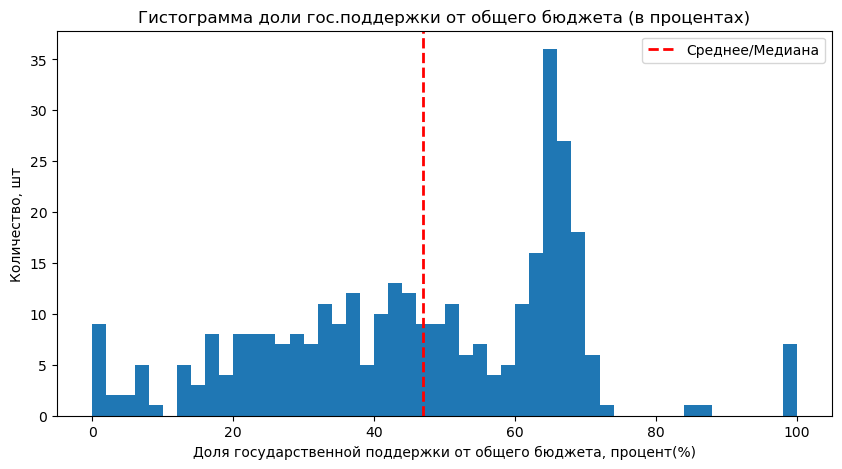

In [144]:
(df['nonrefundable_support'] / df['budget']*100).plot(
    kind = 'hist',
    bins = 50, 
    title = 'Гистограмма доли гос.поддержки от общего бюджета (в процентах)',
    xlabel = 'Доля государственной поддержки от общего бюджета, процент(%)',
    ylabel = 'Количество, шт',
    figsize = (10,5)
)

plt.axvline(x = 47, color='red', linestyle='--', linewidth=2, label='Среднее/Медиана')
plt.legend()
plt.show()

Видим неравномерное распределение с большим пиком в диапозоне 60-70 процентов. Обозначенное выше среднее с пиком не пересекаются. 

**Вывод: государственная поддержка в среднем составляем 47% от общего бюджета фильма.**

---

### Определение периода с наиболее полно представленного данными

- Посмотрите, сколько фильмов выходило в прокат каждый год. Обратите внимание, что данные о прокате в кинотеатрах известны не для всех фильмов. Посчитайте, какую долю составляют фильмы с указанной информацией о прокате в кинотеатрах. Проанализируйте, как эта доля менялась по годам. Сделайте вывод о том, какой период полнее всего представлен в данных.

Создадим сводную таблицу с информации о количестве выходивших фильмов в каждом году. Отметим те, у которых есть данные о прокате, а также кол-во названий без повтров.

In [152]:
year_pivot = df.pivot_table(
    index = 'year',
    values = 'title',
    aggfunc = 'count'
)
year_pivot.rename(columns = {'title':'total_count'}, inplace = True) # переименуем столбец
year_pivot['with_info'] = df.query('box_office.notna()').groupby('year')['title'].count()
year_pivot['share'] = year_pivot.with_info / year_pivot.total_count * 100 # вычислим долю фильмов с указанной информацией о прокате
year_pivot['unique'] = df[~df.title.duplicated()].groupby('year')['title'].count() 

year_pivot

,total_count,with_info,share,unique
year,,,,
2010,976,105,10.76,754
2011,619,109,17.61,471
2012,592,127,21.45,516
2013,629,184,29.25,588
2014,805,279,34.66,725
2015,704,464,65.91,659
2016,817,525,64.26,770
2017,505,357,70.69,495
2018,879,474,53.92,862


Построим график, используя сводную таблицу. Постараемся указать все группы на одном графике, в таком случае соблюдаем последовательность вывода.

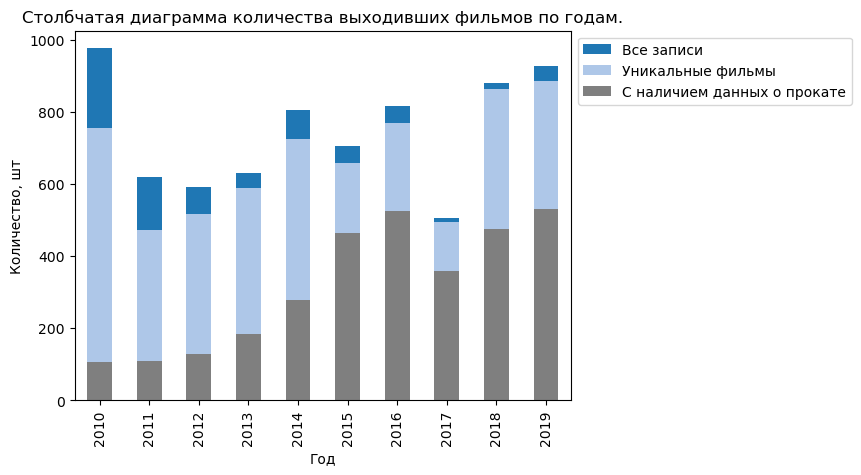

In [154]:
year_pivot.total_count.plot(kind='bar', color='#1f77b4', label='Все записи') # выводим диаграмму общего числа фильмов дл каждого года 
year_pivot.unique.plot(kind='bar', color='#aec7e8', label='Уникальные фильмы') # для примера покажем фильмы, которые до этого не выходили на экраны
year_pivot.with_info.plot(kind='bar', color='#7f7f7f', label='С наличием данных о прокате') # выведем информацию о количестве фильмов с изестными данными о прокате
plt.legend(bbox_to_anchor=(1,1)) # расположим легенду за пределами графика
plt.title('Столбчатая диаграмма количества выходивших фильмов по годам.')
plt.ylabel('Количество, шт')
plt.xlabel('Год')
plt.show()

Наиболее интересный промежуток времени 2015-2019. Доля фильмов с указанной информацией о прокате составляет более 50% для каждого года в обозначенном периоде. Также в нем встречается минимальное кол-во дубликатов.

**Вывод: наиболее полно представлен промежуток с 2015 по 2019 года.**

---

### Динамика проката по годам. Определение среднего и медианы

- Изучите, как менялась динамика проката по годам. В каком году сумма сборов была минимальной? А максимальной?
- С помощью сводной таблицы посчитайте среднюю и медианную сумму сборов для каждого года.

Для ответа на эти вопросы добавим значения среднего и медианы сборов для каждого года в созданную выше сводную таблицу. Отфильтруем данные с 2015 по 2019 года.

In [162]:
new_year_pivot = df.query('year>2014').pivot_table(
    index = 'year',
    values = 'box_office',
    aggfunc = ['sum', 'mean', 'median']
)
new_year_pivot.columns = ['sum', 'mean', 'median'] # устарним двухуровневость заголовков столбцов

filtered_year_pivot = pd.merge(year_pivot, new_year_pivot, how = 'inner', right_index=True, left_index = True) # объединим по индексам

filtered_year_pivot

,total_count,with_info,share,unique,sum,mean,median
year,,,,,,,
2015,704,464,65.91,659,39497363836.40,85123628.96,4946745.45
2016,817,525,64.26,770,47866105214.91,91173533.74,3915041.02
2017,505,357,70.69,495,48563707217.51,136032793.33,9968340.00
2018,879,474,53.92,862,49668361909.32,104785573.65,8911533.94
2019,926,530,57.24,884,48425708779.59,91369261.85,4627798.34


Отсортируем года в порядке возрастания суммы сборов.

In [164]:
filtered_year_pivot.sort_values('sum')

,total_count,with_info,share,unique,sum,mean,median
year,,,,,,,
2015,704,464,65.91,659,39497363836.40,85123628.96,4946745.45
2016,817,525,64.26,770,47866105214.91,91173533.74,3915041.02
2019,926,530,57.24,884,48425708779.59,91369261.85,4627798.34
2017,505,357,70.69,495,48563707217.51,136032793.33,9968340.00
2018,879,474,53.92,862,49668361909.32,104785573.65,8911533.94


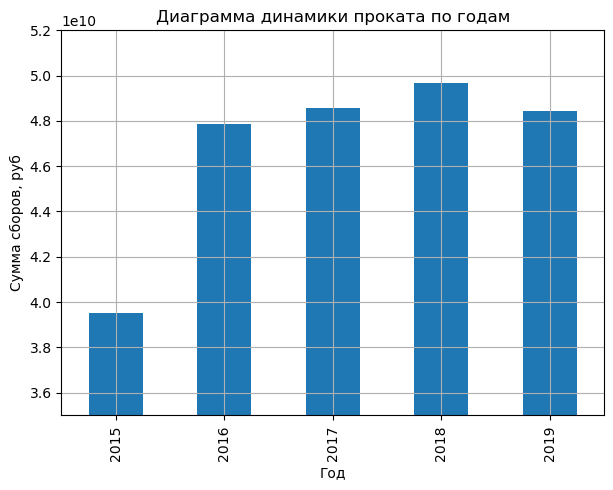

In [165]:
filtered_year_pivot['sum'].plot(
    kind = 'bar',
    title = 'Диаграмма динамики проката по годам',
    ylabel = 'Сумма сборов, руб',
    xlabel = 'Год',
    ylim = (3.5e10, 5.2e10),
    figsize = (7,5),
    grid = True
)
plt.show()

In [166]:
print(f'Минимальная сумма сборов была в 2015 году и составляла {filtered_year_pivot['sum'].min()} руб')
print(f'Максимальная сумма сборов была в 2018 году и составляла {filtered_year_pivot['sum'].max()} руб')

Минимальная сумма сборов была в 2015 году и составляла 39497363836.4 руб
Максимальная сумма сборов была в 2018 году и составляла 49668361909.32 руб


Визуализируем разброс значений сборов кинопроката для каждого года. Покажем разницу среднего и медианы.

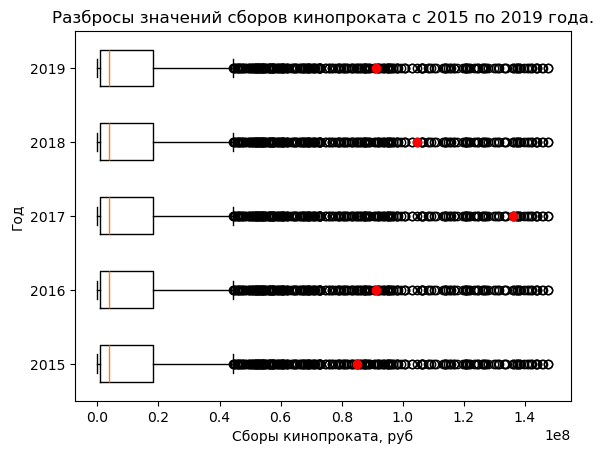

In [168]:
years = [2015, 2016, 2017, 2018, 2019]

plt.boxplot(
    [df[(df.year.isin(years)) & (df.box_office < 0.15e9)]['box_office'] # ограничим значения до 150млн руб
     .dropna() for year in years], #  построим боксплот, передавая список массивов для каждого года с не-NaN значениями box_office
    vert=False,  # Повернем график горизонтально
    labels=years,  # Подписи по годам
    widths = 0.5 # Сделаем коробку более широкой
)
plt.scatter(filtered_year_pivot['mean'], # из созданной ранее сводной таблицы возьмем среднее
            color = 'red', # изменим цвет
            y = range(1, len(years)+1), # передадим значения от 1 до 5, равное кол-ву строк
            zorder = 2 # выведем точки среднего для каждого года на передний план 
           ) 

plt.xlabel('Сборы кинопроката, руб')
plt.ylabel('Год')
plt.title('Разбросы значений сборов кинопроката с 2015 по 2019 года.')
plt.show()

In [169]:
df[df['year'].isin(years)].groupby('year')['box_office'].describe()

,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
2015,464.00,85123628.96,220365361.50,0.00,776810.12,4946745.45,42977118.12,1658861425.50
2016,525.00,91173533.74,251252355.45,0.00,596373.00,3915041.02,38958757.32,2048126108.00
2017,357.00,136032793.33,323251440.97,7900.00,1951257.00,9968340.00,71173828.00,2779686144.00
2018,474.00,104785573.65,272323975.34,42469.00,2432635.67,8911533.94,60308014.17,2271754004.52
2019,530.00,91369261.85,290931159.54,4398.40,1386961.38,4627798.34,38362496.09,3073568690.79


Видим, что значения имеют очень большой разброс: от 0 до 3 млрд руб. Медианы на 1-2 порядка меньше, чем средние значения. Это говорит о большом количестве выбросов, с сильно отличающимися от медианы значениями.

**Интересное наблюдение:**
В 2017 году было выпущено меньше всего фильмов среди периода 2015-2019, однако общая сумма сборов оказалась близка к максимуму за эти годы. Это может свидетельствовать о концентрации фильмов высокого качества в этом году.

**Выводы:**
- **Медианы отличаются от среднего на 1-2 порядка, встречаются мощные выбросы**
- **Минимальная сумма сборов была в 2015 году**
- **Максимальная сумма сборов была в 2018 году**

---

### Влияние возрастного ограничения на сумму проката

- Определите, влияет ли возрастное ограничение аудитории («6+», «12+», «16+», «18+» и т. д.) на сборы фильма в прокате в период с 2015 по 2019 год? Фильмы с каким возрастным ограничением собрали больше всего денег в прокате? Меняется ли картина в зависимости от года? Если да, предположите, с чем это может быть связано.

Отфильтруем df с фильмами, вышедшими после 2014 года.

In [178]:
df_year_filtered = df.query('year>2014')

Для проверки линейной зависимости возрастного ограничения и суммы сборов за год посчитаем корреляцию Пирсона, расставим коэффициенты для категориального столбца.

In [180]:
age_mapping = {'0+': 1,'6+': 2, '12+': 3, '16+': 4, '18+': 5}

# Корреляция Пирсона между кодированным возрастом и сборами
correlation = df_year_filtered['age_restriction'].map(age_mapping).corr(df.query('year>2014')['box_office'])
print("Корреляция между возрастным ограничением и сборами:", correlation)

Корреляция между возрастным ограничением и сборами: -0.12033897787093095


Линейной зависимости не обнаружено.

Создадим сводную таблицу, где будет информация о сумме сборов для каждого года, в промежутке с 2015 по 2019, и каждого возрастного ограничения. Также добавим столбец с общей суммой сборов для каждой строки сводной таблицы.

In [183]:
age_pivot = df_year_filtered.pivot_table(index = 'age_restriction', values = 'box_office', aggfunc = 'sum', columns = 'year')
age_pivot = age_pivot.reindex(['0+', '6+', '12+', '16+', '18+']) # передаем методу нужный порядок индексов
age_pivot['total'] = age_pivot.sum(axis = 1)
age_pivot

year,2015,2016,2017,2018,2019,total
age_restriction,,,,,,
0+,379053218.37,150034321.67,229598930.00,32449002.11,17746066.82,808881538.97
6+,8701799371.41,12053146008.24,12086142145.76,10104974623.41,12852548650.86,55798610799.68
12+,13616082008.91,12204446524.39,7851427660.67,14267250435.69,12680198773.67,60619405403.33
16+,11368120870.27,16664548541.74,18745042900.06,16503602346.96,12753418984.60,76034733643.63
18+,5432308367.44,6793929818.87,9651495581.02,8760085501.15,10121796303.64,40759615572.12


Визуализируем общую сумму сборов для каждой категории.

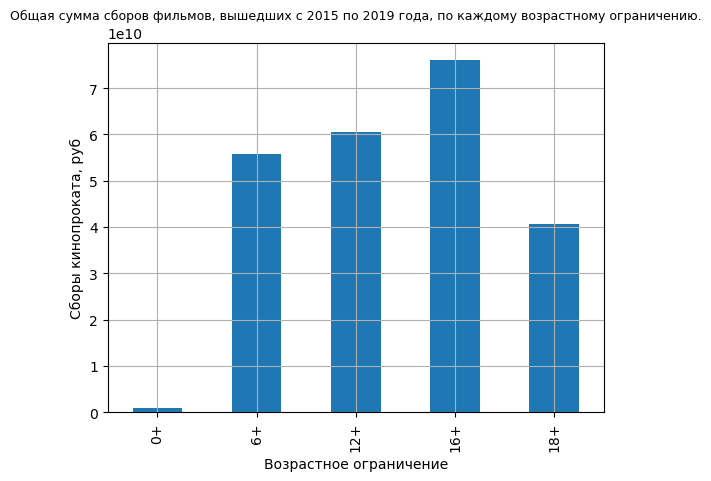

In [185]:
age_pivot['total'].plot(kind = 'bar', grid = True)
plt.ylabel('Сборы кинопроката, руб')
plt.xlabel('Возрастное ограничение')
plt.title('Общая сумма сборов фильмов, вышедших с 2015 по 2019 года, по каждому возрастному ограничению.', fontsize =9)
plt.show()

Максимальную сумму сборов с 2015 по 2019 показали фильмы с возрастным ограничением 16+.

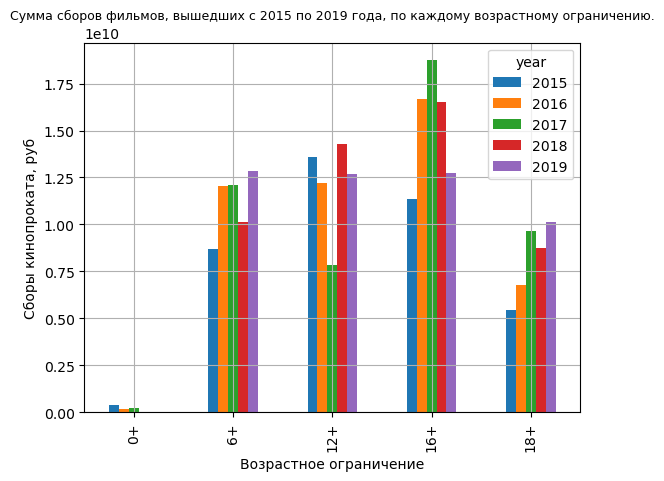

In [187]:
age_pivot[[2015, 2016, 2017, 2018, 2019]].plot(kind = 'bar', grid = True) # Избежим вывода столбца `total`
plt.ylabel('Сборы кинопроката, руб')
plt.xlabel('Возрастное ограничение')
plt.title('Сумма сборов фильмов, вышедших с 2015 по 2019 года, по каждому возрастному ограничению.', fontsize =9)
plt.show()

Однако, делать выводы по сумме проката за год для категорий может быть не достоверно, тк в каждый год выходило разное количество фильмов, чтобы учесть эту переменную при анализе динамики высчитаем среднюю сумму сборов для каждой категории и года.

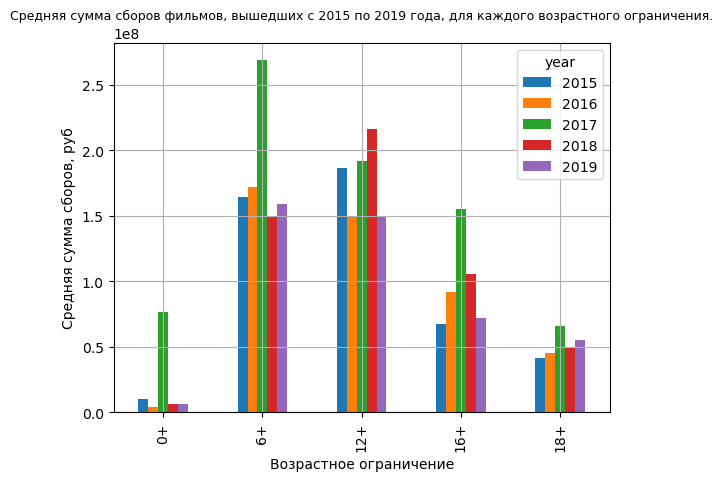

In [189]:
( 
    df_year_filtered
    .pivot_table(index = 'age_restriction', values = 'box_office', aggfunc = 'mean', columns = 'year')
    .reindex(['0+', '6+', '12+', '16+', '18+']) # Поменяем порядок вывода строк
    .plot(kind = 'bar', grid = True)
)
plt.ylabel('Средняя сумма сборов, руб')
plt.xlabel('Возрастное ограничение')
plt.title('Средняя сумма сборов фильмов, вышедших с 2015 по 2019 года, для каждого возрастного ограничения.', fontsize =9)
plt.show()

Возвращаясь к пункту 3.2, общая средняя за 2017 была выше остальных, теперь видим, что это свойственно и для каждой возрастной категори в 2017. 

Категория 12+ показала самую высокую среднюю в 2015 и 2018 годах; 6+ - в 2016 и 2019 (с небольшим отрывом от 12+ в обоих годах) и в 2017. 

Если не учитывать выбивающиейся значения 2017ого, с 2015 по 2019 года распределение средних было примерно одинаково. Последовательность в порядке возрастания: 0+, 18+, 16+, 6+/12+. Средние суммы сборов для категорий 6+ и 12+ примерно равны.

Фильмы 6+ и 12+ ориентированы на семьи с детьми, привлекая, соответственно, более широкую аудиторию.

**Выводы:**
- **Линейной зависимости между возрастной категорией фильма и суммой сбора не обнаружено;**
- **Суммарно с 2015 по 2019 больую сумму проката собрала категория 16+;**
- **Последовательность средних сборов для возрастных категорий в порядке возрастания: 0+, 18+, 16+, 6+/12+.**

---

### Исследование фильмов с государственной поддержкой

На этом этапе нет конкретных инструкций и заданий — поищите интересные закономерности в данных. Посмотрите, сколько выделяют средств на поддержку кино. Проверьте, хорошо ли окупаются такие фильмы, какой у них рейтинг.

Создадим отдельный df, куда попадут фильмы, выходившие с 2015 года и не имещие пропуски в столбце гос. поддержки.

In [196]:
df_gov_support = df_year_filtered[df_year_filtered.nonrefundable_support.notna()].copy()

Сколько ежегодно выделяется из бюджета на поддержку кинематографа.

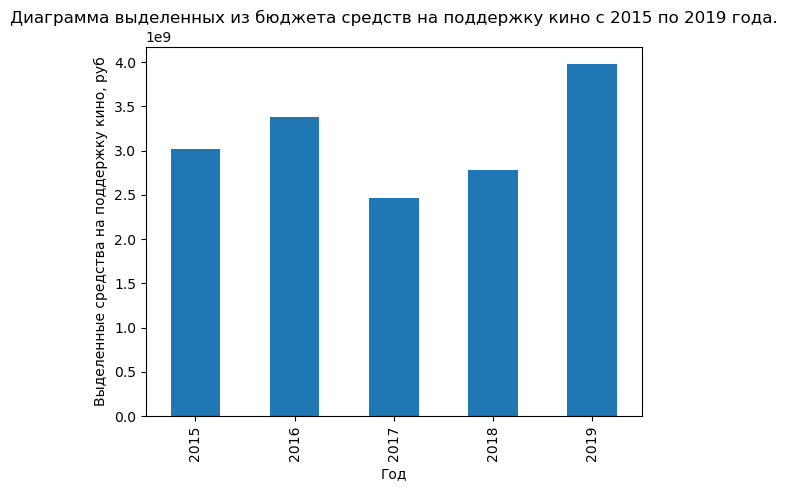

In [198]:
df_gov_support.groupby('year')['nonrefundable_support'].sum().plot(kind = 'bar')
plt.ylabel('Выделенные средства на поддержку кино, руб')
plt.xlabel('Год')
plt.title('Диаграмма выделенных из бюджета средств на поддержку кино с 2015 по 2019 года.')
plt.show()

Каждый год выделяют от 2,5 до 4 млрд руб.

---

Для изучения окупаемости фильмов добавим столбец `profitability`, значение которого - соотношение сборов фильма к его бюджету.

In [202]:
df_gov_support['profitability'] = round(df_gov_support['box_office'] / df_gov_support['budget'], 2)

Построим гистограмму окупаемости фильмов.

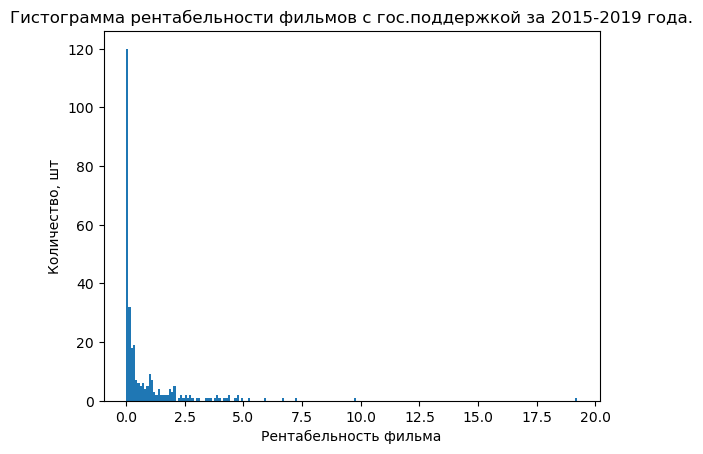

In [204]:
df_gov_support.profitability.plot(kind = 'hist', bins = 200)
plt.ylabel('Количество, шт')
plt.xlabel('Рентабельность фильма')
plt.title('Гистограмма рентабельности фильмов с гос.поддержкой за 2015-2019 года.')
plt.show()

In [205]:
print(f'Доля окупивших себя фильмов с государственной поддержкой за 2015-2019 года составляет {((df_gov_support.profitability > 1) / df_gov_support.profitability.count()).sum().round(2) *100}%')

Доля окупивших себя фильмов с государственной поддержкой за 2015-2019 года составляет 25.0%


In [206]:
for year in years:
    print('Доля в',year,':', ((df_gov_support.query('year == @year').profitability > 1) / df_gov_support.query('year == @year').profitability.count()).sum().round(2)*100,'%')

Доля в 2015 : 21.0 %
Доля в 2016 : 18.0 %
Доля в 2017 : 38.0 %
Доля в 2018 : 34.0 %
Доля в 2019 : 18.0 %


Средняя окупаемость фильмов с гос.поддержкой за 5 лет составила 25%, однако макисмальная, закономерно, была в 2017 году - 38%.

**Выводы:**
- **С 2015 по 2019 года выделялось 2,5-4 млрд руб ежегодно;**
- **В среднем за 2015-2019 года окупалась только четверть фильмов, получивших гос поддержку.**

## Общий вывод

**По результатам проделланой работы можно сделать следующие выводы:**
- **Государственная поддержка в среднем составляем 47% от общего бюджета фильма**
- **Наиболее полно в датасете представлен промежуток с 2015 по 2019 года**
- **Медианы сумм сборов за каждый год отличаются от их среднего на 1-2 порядка, встречаются мощные выбросы**
- **Минимальная сумма сборов была в 2015 году**
- **Максимальная сумма сборов была в 2018 году**
- **Линейной зависимости между возрастной категорией фильма и суммой сбора не обнаружено**
- **Суммарно с 2015 по 2019 больую сумму проката собрала категория 16+**
- **Последовательность средних сумм сборов для возрастных категорий в порядке возрастания: 0+, 18+, 16+, 6+/12+**
- **С 2015 по 2019 года из бюджета выделялось 2,5-4 млрд руб ежегодно на поддержку кино**
- **В среднем за 2015-2019 года окупалась только четверть фильмов, получивших гос поддержку.**